<a href="https://colab.research.google.com/github/IntroComputationalPhysics-UNT/euler-and-solve-ivp-dylanfranklin469/blob/main/Franklin_HW_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##Pseudocode for solving the ridgid pendulum problem
1.  **Import Packages:** import `matplotlib.pyplot` for plotting; `math` for periodic functions, and pi.
2. **Define Differential Equation:** Convert  $\ddot\theta + \omega_0^2 sin(\theta)$ to a linear system: where $\theta_[n+1] = \theta_n + \Omega_n \Delta t$ and
$Ω_[n+1] = \Omega_n - \omega_0^2 sin(\theta_n) \Delta t$

3.  **Define the initial condutions, input parameters, and the time span:** define `theta_0`, `ang_vel_0`, `n_steps`, `y_0`, and `t_f & t_0`.
4. **Solve the Differential Equation:** call `EulerCode`
5. **Plot and explore solution:** plot the temporal evolution, and a phase portrait, and compare with approximate solutions.


Problem 1.2: where theta_0 = math.pi & ang_vel_0 = 0


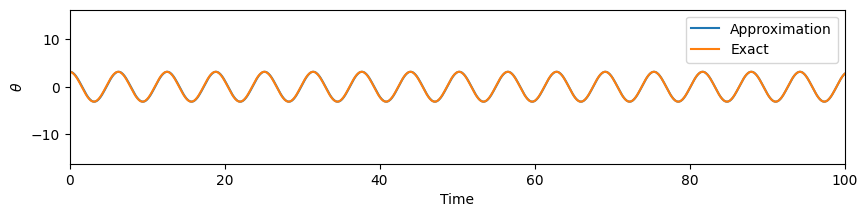

Problem 1.3: where theta_0 = 0 & ang_vel_0 = 2


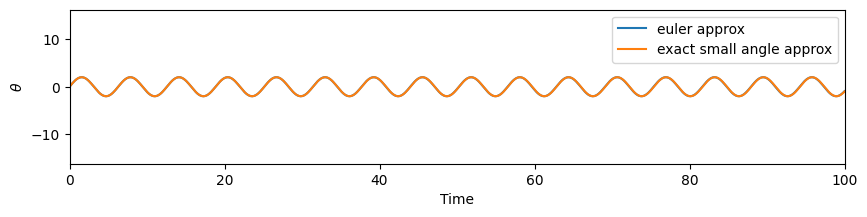

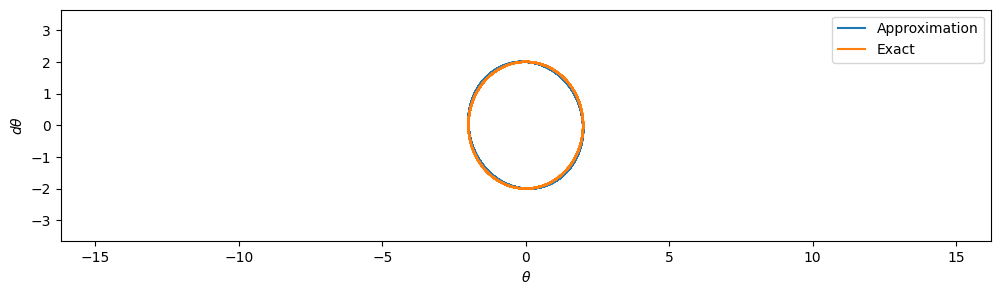

In [93]:
import math
import matplotlib.pyplot as plt
import numpy as np


def EulerCode(t_0,t_f,n_steps,ang_vel_0,theta_0,omega_0):
  dt = (t_f - t_0) / n_steps
  theta = [theta_0]
  ang_vel = [ang_vel_0]
  t = [t_0]
  for _ in range(n_steps):
    theta_new = theta[-1] + ang_vel[-1] * dt
    ang_vel_new = ang_vel[-1] - omega_0**2 * theta_new * dt
    #ang_vel_new = ang_vel[-1] - omega_0**2 * theta[-1] * dt
    t_new = t[-1] + dt
    theta.append(theta_new)
    ang_vel.append(ang_vel_new)
    t.append(t_new)

  return t, theta, ang_vel

omega_0 = 1
n_steps = 1000
t_0 = 0
t_f = 100



theta_0 = math.pi   #These var. assignments are for 1.2, they will be updated later for 1.3
ang_vel_0 = 0


t, theta, ang_vel = EulerCode(t_0,t_f,n_steps,ang_vel_0,theta_0, omega_0)


theta_exact = [theta_0 * math.cos(omega_0 * (t[i] - t_0)) + (ang_vel_0 / omega_0) * math.sin(omega_0 * (t[i] - t_0)) for i in range(len(t))] # using list comprehension
ang_vel_exact = [- theta_0 * omega_0 * math.sin(omega_0 * (t[i] - t_0)) + ang_vel_0 * math.cos(omega_0 * (t[i] - t_0)) for i in range(len(t))] # using list comprehension



print("Problem 1.2: where theta_0 = math.pi & ang_vel_0 = 0")
#temporal evolution of theta
plt.figure(figsize=(10,2))
plt.xlim([0, 100]) # time
plt.ylim([- 5 * math.pi - 0.5, 5 * math.pi + 0.5]) # theta
plt.plot(t, theta, label='Approximation')
plt.plot(t,theta_exact, label='Exact')
plt.xlabel("Time")
plt.ylabel("$\\theta$")
plt.legend()
plt.show()



print("Problem 1.3: where theta_0 = 0 & ang_vel_0 = 2")
theta_0 = 0  #Updated vars for 1.3
ang_vel_0 = 2
t, theta, ang_vel = EulerCode(t_0,t_f,n_steps,ang_vel_0,theta_0,omega_0)  # New vals for theta_0 = 0, ang_vel_0 = 0

theta_exact = [theta_0 * math.cos(omega_0 * (t[i] - t_0)) + (ang_vel_0 / omega_0) * math.sin(omega_0 * (t[i] - t_0)) for i in range(len(t))] # using list comprehension
ang_vel_exact = [- theta_0 * omega_0 * math.sin(omega_0 * (t[i] - t_0)) + ang_vel_0 * math.cos(omega_0 * (t[i] - t_0)) for i in range(len(t))] # using list comprehension

#temporal evolution
plt.figure(figsize=(10,2))
plt.xlim([0, 100]) # time
plt.ylim([- 5 * np.pi - 0.5, 5 * np.pi + 0.5]) # theta
plt.plot(t, theta, label='euler approx')
plt.plot(t,theta_exact, label='exact small angle approx')
plt.xlabel("Time")
plt.ylabel("$\\theta$")
plt.legend()
plt.show()
#phase portrait
plt.figure(figsize=(12,3))
plt.xlim([- 5 * np.pi - 0.5, 5 * np.pi + 0.5]) # theta
plt.ylim([-  np.pi - 0.5,  np.pi + 0.5]) # angular velocity
plt.plot(theta,ang_vel,label='Approximation')
plt.plot(theta_exact,ang_vel_exact,label='Exact')


plt.xlabel("$\\theta$")
plt.ylabel("$d\\theta$")
plt.legend()
plt.show()
%reset -f


##Simple Euler Method:
 For each step (dt):
- ${\Omega_n} = {\Omega_{n-1}} - \omega_0 sin(\theta_n)dt$
- $\theta_n = \theta_{n-1} + {\Omega_n}dt$ \
##Symplectic Euler Method:
For each step (dt):
- ${\Omega_n} = {\Omega_{n-1}} - \omega_0 sin(\theta_n)dt$
- $\theta_n = \theta_{n-1} + {\Omega_n}dt$, where $\Omega_n$ is updated from the above line



##Comparing both methods
Using the Simple Euler Method tends to have unstable energy conservation over time. Using the Sympletic Euler Method allows for updating while running because the omega term is taken from the previous calculation. You can see this extremely clearly by replacing the code with the # line containing:
    `ang_vel_new = ang_vel[-1] - omega_0**2 * theta[-1] * dt`
. If we adjust the mesh density to 10,000, we find that the data is further accurate for sensable information.






##Problem 2 Pseudocode:
1. **Import Packages**: import `numpy`, `pyplot`, and `solve_ivp from scipy.integrate`.
2. **Define differential equation:**

$y = [\theta, \Omega]$ so, $dy/dt = [d\theta / dt, d^2\theta/dt$]

$d\theta / dt = \Omega$ \
$d^2\theta / dt^2 = -\omega_0^2 sin(\theta)$

So, $dy/dt = [\Omega,-\omega_0^2 sin(\theta)]$ \
3. **Solve differential equation:** Call `pendulumODE` \
4. **Plot and explore solution:** plot the temporal evolution, and a phase portrait, and compare with approximate solutions.

         0   0.000000000000   0.000100000000
         1   0.000100000000   0.001000000000
         2   0.001100000000   0.010000000000
         0   0.000000000000   0.000499750125
         1   0.000499750125   0.004997501249
         2   0.005497251374   0.049975012494


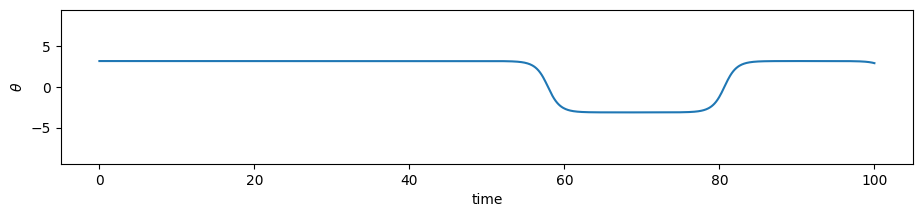

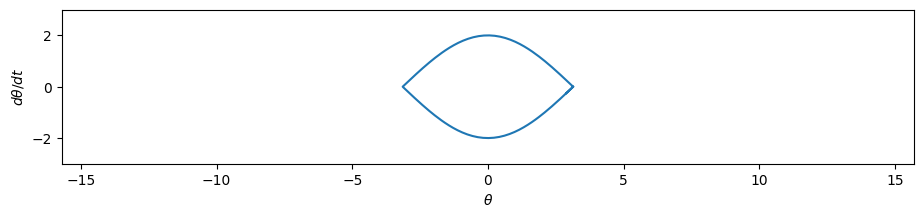

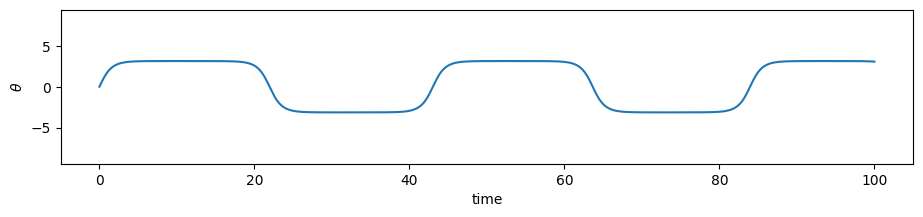

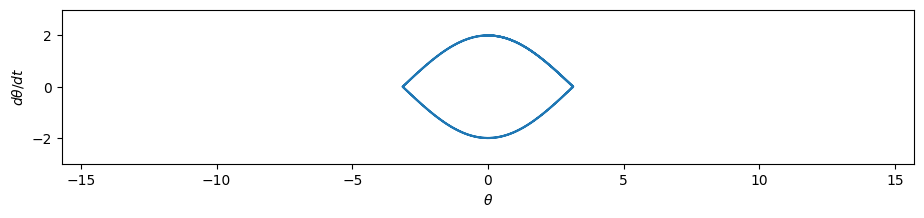

In [97]:

#import packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

#define difeq
def pendulumODE(t,y,omega_0 = 1): #this has to be time and then state for the differential equation solver
  """
  Returns the time derivative of y = [theta, ang_vel] (the angle and angular velocity)
  """
  theta, ang_vel = y                               #unpacks y=[thera, ang_vel]
  dtheta_dt = ang_vel                              #define first derivative
  d2theta_dt2 = - omega_0 ** 2 * np.sin(theta)     #define second derivative
  dy_dt = [dtheta_dt, d2theta_dt2]                  #define derivative of state variable
  return dy_dt                                     # We could do this in one line, but for simplicity sake we wont

  #Initial conditions for 2.2
theta_0 = np.pi               #initial angle
ang_vel_0 = 0               #initial angular velocity
y_0 = [theta_0, ang_vel_0]  #initial state

  #Input Parameters
omega_0 = 1 #natural frequency

  #Time Span
t_initial = 0     #initial time
t_final = 100     #final time
t_span = [t_initial, t_final] #time span

  #Solve Differential Equation
solution = solve_ivp(pendulumODE,t_span,y_0, args=(omega_0,),dense_output=True, max_step=.08)   #the , is used for args because we watn to make sure that it knows it is a tuple, not just arithmetic operator
                                                                                  #t_eval allows you to tell what points you want an output at
                                                                                  #dense_output: bool; whether to compute a continuous solution, we now have sol.
solution #second part of y is the angular velocity, the package does step size as well


#explore output of solve_ivp
t_eval = solution.t
t_eval_diff = np.diff(t_eval)
for i in range(3):
  print(f"{i:>10d} {t_eval[i]:>16.12f} {t_eval_diff[i]:>16.12f}")



n_steps = 1000
t_plot = np.linspace(t_initial,t_final, n_steps) # list of times for plotting
ang_vel_plot = solution.sol(t_plot)[1]           # solution for plotting : angle
theta_plot = solution.sol(t_plot)[0]             # solution for plotting : angular velocity

#temporal evolution
plt.figure(figsize=(11,2))
plt.plot(t_plot,theta_plot)
plt.xlabel("time")
plt.ylabel("$\\theta$")
plt.ylim(-3 * np.pi, 3* np.pi)
#phase portrait
plt.figure(figsize=(11,2))
plt.plot(theta_plot, ang_vel_plot)
plt.xlabel("$\\theta$")
plt.ylabel("$d\\theta / dt$")
plt.xlim(-5*np.pi,5*np.pi)
plt.ylim(-3,3)



#Initial conditions for 2.3
theta_0 = 0               #initial angle
ang_vel_0 = 2               #initial angular velocity
y_0 = [theta_0, ang_vel_0]  #initial state

  #Input Parameters
omega_0 = 1 #natural frequency

  #Time Span
t_initial = 0     #initial time
t_final = 100     #final time
t_span = [t_initial, t_final] #time span

  #Solve Differential Equation
solution = solve_ivp(pendulumODE,t_span,y_0, args=(omega_0,),dense_output=True, max_step=.1)   #the , is used for args because we watn to make sure that it knows it is a tuple, not just arithmetic operator
                                                                                  #t_eval allows you to tell what points you want an output at
                                                                                  #dense_output: bool; whether to compute a continuous solution, we now have sol.
solution #second part of y is the angular velocity, the package does step size as well


#explore output of solve_ivp
t_eval = solution.t
t_eval_diff = np.diff(t_eval)
for i in range(3):
  print(f"{i:>10d} {t_eval[i]:>16.12f} {t_eval_diff[i]:>16.12f}")



n_steps = 1000
t_plot = np.linspace(t_initial,t_final, n_steps) # list of times for plotting
ang_vel_plot = solution.sol(t_plot)[1]           # solution for plotting : angle
theta_plot = solution.sol(t_plot)[0]             # solution for plotting : angular velocity

#temporal evolution
plt.figure(figsize=(11,2))
plt.plot(t_plot,theta_plot)
plt.xlabel("time")
plt.ylabel("$\\theta$")
plt.ylim(-3 * np.pi, 3* np.pi)


#phase portrait
plt.figure(figsize=(11,2))
plt.plot(theta_plot, ang_vel_plot)
plt.xlabel("$\\theta$")
plt.ylabel("$d\\theta / dt$")
plt.xlim(-5*np.pi,5*np.pi)
plt.ylim(-3,3)
solve_ivp?
%reset -f

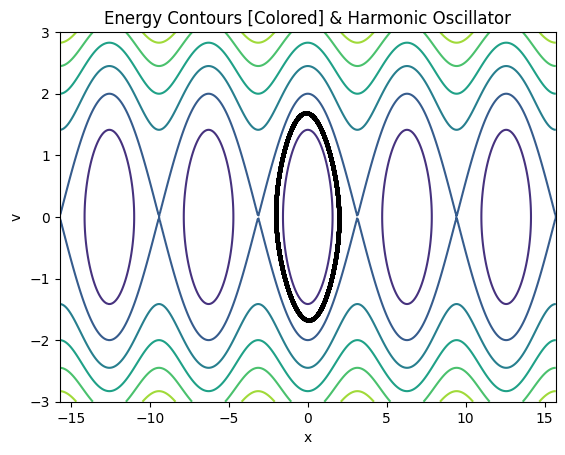

In [96]:
import matplotlib.pyplot as plt
import numpy as np
# define our test euler method for a simple harmonic oscillator
def euler_pend(omega_0, x_0, v_0, t_0, t_f, n_steps):
  """
  This function calculates the solution to x'' = - omega_0 ^2 x with Euler's method.
  """
  dt = (t_f - t_0) / n_steps # calculate dt
  x = [x_0] # initialized x list
  v = [v_0] # initialized v list
  t = [t_0] # initialized t list
  for _ in range(n_steps):
    x_new = x[-1] + v[-1] * dt # update x
    v_new = v[-1] - omega_0 ** 2 * np.sin(x_new) * dt # update v : using an implicit form
    t_new = t[-1] + dt # update t
    x.append(x_new) # append x
    v.append(v_new) # append v
    t.append(t_new) # append t
  return np.array(t), np.array(x), np.array(v) #Returns a numpy array so that we can easily do multiplecation to each element later

x_0 = 2 #initial x pos
v_0 = 0 #initial velocity
omega_0 = 1
t_0 = 0 #initial time
t_f = 100 #final time
n_steps = 1000 #steps
t, x, v = euler_pend(omega_0, x_0, v_0, t_0, t_f, n_steps) #return each from function

x_space = np.linspace(-5*np.pi, 5*np.pi, 500) #initializing x's for the energy contours
v_space = np.linspace(-3,3,400)               #initializing v for energy contour
X, V = np.meshgrid(x_space,v_space)           #create coordinates on the plot from vectors
E = .5 * V**2 + omega_0**2 * (1-np.cos(X))    #Formula for energy, inputs X, V coordinates initialized before
plt.contour(X, V, E)                          #Plots energy contours with color corresponding with E

plt.plot(x, v, color='black',linewidth=3)    #Plots the function we calculated with the euler_pend(x_0 = 2, and v_0 = 0) conditions
plt.xlim(-5*np.pi, 5*np.pi)                  #Sets x bounds
plt.ylim(-3, 3)                              #Sets y bounds
plt.xlabel("x")                              #X label
plt.ylabel("v")                              #Y label
plt.title("Energy Contours [Colored] & Harmonic Oscillator")
plt.show()


We can see from this graph, that starting the pendulum at $v_0 = 0$ will have the graph be sitting around a lower energy state. If we changed $v_0$, we can see the respective black line expanding to higher energies.
